# dbt Test Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/dbt-test-gen/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/dbt-test-gen/demo.ipynb)

> No tests on our models. This profiles a table and auto-generates a paste-ready dbt schema.yml.

Everyone agrees models should have tests. Nobody writes them, because writing `not_null` /
`unique` / `accepted_values` by hand across 40 columns is tedious. So we profile the data and let
the *evidence* suggest the tests - then emit a `schema.yml` you can drop straight into dbt.

**What this notebook covers**
1. Profiling a column to decide which tests fit
2. Inferring `unique`, `not_null`, `accepted_values`, and `relationships`
3. Rendering a real dbt `schema.yml`
4. Measuring test coverage
5. Coverage before vs after, visualized


## Step 1 - Let the data suggest the tests

Each test maps to a profile signal: no nulls → `not_null`; nearly all-distinct → `unique`; a handful
of repeated text values → `accepted_values`; a `*_id` name → `relationships`. Every suggestion
carries its reason, so a human can sanity-check it.

In [1]:
from testgen import generate_model_tests, to_schema_yml, coverage, sample_dataframe

df = sample_dataframe()
cts = generate_model_tests(df)
for ct in cts:
    print(f"{ct.name:<10} {ct.tests}")
    for test, why in ct.reason.items():
        print(f"    - {test}: {why}")


id         ['not_null', 'unique']
    - not_null: 0% null in sample
    - unique: 100% distinct + key-like name
user_id    ['not_null', 'relationships']
    - not_null: 0% null in sample
    - relationships: name 'user_id' implies FK to users.user_id or id
status     ['not_null', 'accepted_values']
    - not_null: 0% null in sample
    - accepted_values: 3 distinct categories
plan       ['not_null', 'accepted_values']
    - not_null: 0% null in sample
    - accepted_values: 3 distinct categories
amount     ['not_null']
    - not_null: 0% null in sample
email      ['not_null', 'unique']
    - not_null: 0% null in sample
    - unique: 100% distinct values


## Step 2 - Note what it *doesn't* suggest

Good defaults are as much about restraint as coverage. `email` is unique, so it gets `unique` - but
**not** `accepted_values`, because a near-unique column is a key, not an enum. Firing an enum test on
every email would create 6 false "failures" the moment a new email appears.

In [2]:
email = next(ct for ct in cts if ct.name == "email")
print("email tests:", email.tests)
print("-> correctly NOT accepted_values (it's a key, would break on any new value)")

status = next(ct for ct in cts if ct.name == "status")
print("\nstatus tests:", status.tests, "| accepted_values:", status.accepted_values)


email tests: ['not_null', 'unique']
-> correctly NOT accepted_values (it's a key, would break on any new value)

status tests: ['not_null', 'accepted_values'] | accepted_values: ['paid', 'pending', 'refunded']


## Step 3 - Render a real schema.yml

The output is valid dbt. Copy it into `models/`, run `dbt test`, and you have coverage you didn't
have to hand-write.

In [3]:
print(to_schema_yml("orders", cts, "Order line items"))


version: 2

models:
  - name: orders
    description: "Order line items"
    columns:
      - name: id
        tests:
          - not_null
          - unique
      - name: user_id
        tests:
          - not_null
          - relationships:
              to: ref('users')
              field: id
      - name: status
        tests:
          - not_null
          - accepted_values:
              values: ["paid", "pending", "refunded"]
      - name: plan
        tests:
          - not_null
          - accepted_values:
              values: ["free", "pro", "team"]
      - name: amount
        tests:
          - not_null
      - name: email
        tests:
          - not_null
          - unique


## Step 4 - Coverage in a number

"Do our models have tests?" gets a real answer: percent of columns with at least one test, and the
mix of test types.

In [4]:
cov = coverage(cts)
print(f"Columns tested: {cov['tested']}/{cov['total']}  ({cov['pct']}%)")
print("Tests by type:", cov["by_test"])


Columns tested: 6/6  (100%)
Tests by type: {'not_null': 6, 'unique': 2, 'relationships': 1, 'accepted_values': 2}


## Step 5 - Before vs after, visualized

The starting point is almost always zero. One pass takes coverage from nothing to nearly complete -
that's the whole pitch.

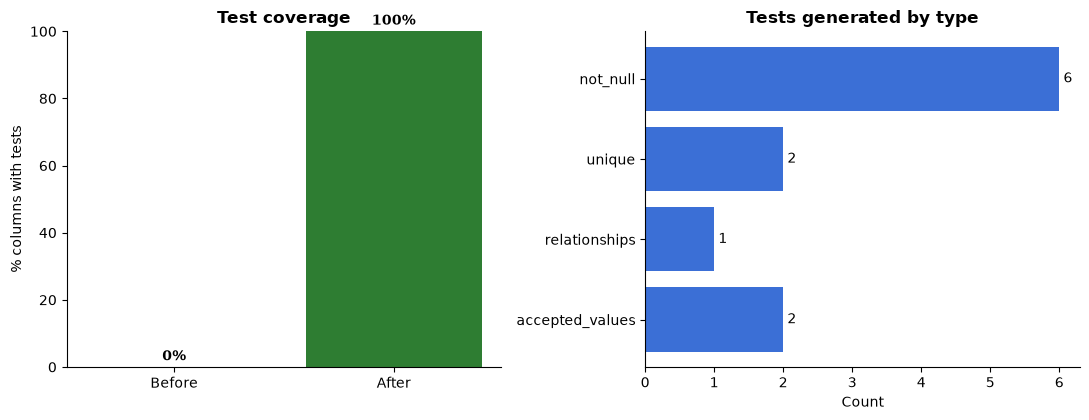

In [5]:
import matplotlib.pyplot as plt

by_test = cov["by_test"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))

ax1.bar(["Before", "After"], [0, cov["pct"]], color=["#c0553b", "#2e7d32"])
ax1.set_ylim(0, 100)
ax1.set_ylabel("% columns with tests")
ax1.set_title("Test coverage", fontsize=12, weight="bold")
for i, v in enumerate([0, cov["pct"]]):
    ax1.text(i, v + 2, f"{v}%", ha="center", weight="bold")
ax1.spines[["top", "right"]].set_visible(False)

names = list(by_test)
vals = [by_test[k] for k in names]
bars = ax2.barh(names[::-1], vals[::-1], color="#3b6fd6")
ax2.set_title("Tests generated by type", fontsize=12, weight="bold")
ax2.set_xlabel("Count")
ax2.bar_label(bars, padding=3)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("coverage.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Column | Suggested tests |
|--------|-----------------|
| id | not_null, unique |
| user_id | not_null, relationships → users |
| status | not_null, accepted_values |
| plan | not_null, accepted_values |
| amount | not_null |
| email | not_null, unique |

Profile-driven, explainable, and restrained. It won't replace a data engineer's judgment - it
removes the excuse of "tests are too tedious to start."

**Extend it:** read the schema from your warehouse's `information_schema`, add `dbt_utils`
range/expression tests for numeric columns, and open a PR with the generated `schema.yml`.

In [6]:
# --- Try your own table ---
# import pandas as pd
# my_df = pd.read_csv("your_model.csv")
# print(to_schema_yml("my_model", generate_model_tests(my_df)))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 103,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`